# RL Experiment Plots

Visualize training metrics from RL experiments across three settings:
- `real_world`
- `simulation`
- `simulation_with_real_world_input`

Metrics: `ep_len_mean`, `ep_rew_mean`, `top_score`

In [1]:
from tbparse import SummaryReader
import pandas as pd
import os

# log_dir = "/home/wsl/mygit/rwrl_backup/runs/AtlantisNoFrameskip-v4/DQN_1/events.out.tfevents.1773319891.A512025.293052.0"
# output_dir = "/home/wsl/mygit/rwrl_backup/runs/AtlantisNoFrameskip-v4/DQN_1/"
# log_dir = "C:\\GitHub\\data_and_plot\\wgzqrmn3\\tensorboard\\breakout_20260401_000009\\events.out.tfevents.1774962009.b3611ff33acb.2909.0"
# output_dir = "C:\\GitHub\\data_and_plot\\ep_rew_mean\\wgzqrmn3\\"
log_dir = "C:\\GitHub\\data_and_plot\\wgzqrmn3\\tensorboard\\breakout_20260529_224645\\events.out.tfevents.1780058805.b3611ff33acb.7836.0"
output_dir = "C:\\GitHub\\data_and_plot\\wgzqrmn3\\csv\\breakout_20260529\\"
# log_dir = "C:\\GitHub\\data_and_plot\\10_66_28_74\\tensorboard\\breakout_20260424_231658\\events.out.tfevents.1777036618.f9131d64a981.2853.0"
# output_dir = "C:\\GitHub\\data_and_plot\\10_66_28_74\\csv\\breakout_20260424_231658\\"

os.makedirs(output_dir, exist_ok=True)

reader = SummaryReader(log_dir, extra_columns={'wall_time'})

# Export scalars
df = reader.scalars
df.to_csv(os.path.join(output_dir, "scalars.csv"), index=False)

for tag, group in df.groupby("tag"):
    safe_tag = tag.split("/", 1)[-1]
    print(f"Exporting tag: {tag} to {safe_tag}.csv with columns: {group.columns.tolist()}")

    # Drop tag and dir_name columns if they exist
    group = group.drop(columns=["tag"], errors="ignore")

    # If wall_time exists, move it to the front
    if "wall_time" in group.columns:
        cols = ["wall_time"] + [c for c in group.columns if c != "wall_time"]
        group = group[cols]
    # Rename wall_time → "Wall time"
    group = group.rename(columns={"wall_time": "Wall time"})
    group.columns = [col.capitalize() for col in group.columns]

    out_path = os.path.join(output_dir, f"{safe_tag}.csv")
    group.to_csv(out_path, index=False)

# # Export histograms
# if reader.histograms is not None:
#     reader.histograms.to_csv(os.path.join(output_dir, "histograms.csv"), index=False)

# # Export tensors
# if reader.tensors is not None:
#     reader.tensors.to_csv(os.path.join(output_dir, "tensors.csv"), index=False)

# # Export text
# if reader.text is not None:
#     reader.text.to_csv(os.path.join(output_dir, "text.csv"), index=False)

# # Export images metadata (not the raw images)
# if reader.images is not None:
#     reader.images.to_csv(os.path.join(output_dir, "images.csv"), index=False)

print("All TensorBoard data exported to CSV.")

Exporting tag: rollout/ep_len_mean to ep_len_mean.csv with columns: ['step', 'tag', 'value', 'wall_time']
Exporting tag: rollout/ep_rew_mean to ep_rew_mean.csv with columns: ['step', 'tag', 'value', 'wall_time']
Exporting tag: rollout/exploration_rate to exploration_rate.csv with columns: ['step', 'tag', 'value', 'wall_time']
Exporting tag: rollout/top_score to top_score.csv with columns: ['step', 'tag', 'value', 'wall_time']
Exporting tag: time/episodes to episodes.csv with columns: ['step', 'tag', 'value', 'wall_time']
Exporting tag: time/fps to fps.csv with columns: ['step', 'tag', 'value', 'wall_time']
Exporting tag: time/total_steps to total_steps.csv with columns: ['step', 'tag', 'value', 'wall_time']
Exporting tag: train/loss to loss.csv with columns: ['step', 'tag', 'value', 'wall_time']
All TensorBoard data exported to CSV.


In [2]:
import sys
from pathlib import Path
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

root_dir = Path("..").resolve()
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

import plot_functions
importlib.reload(plot_functions)
from plot_functions import plot_learning_curves

import style
importlib.reload(style)
from style import MatplotlibStyle

mpl_style = MatplotlibStyle()
mpl_style.apply()

In [3]:
def read_rl_csv(metric: str, key: str, base_dir: str = ".") -> pd.DataFrame:
    """
    Read an RL training CSV file by metric folder and file key.

    Args:
        metric:   subfolder name, e.g. "ep_len_mean", "ep_rew_mean", "top_score"
        key:      file stem, e.g. "real_world", "simulation",
                  "simulation_with_real_world_input"
        base_dir: root directory that contains the metric folders (default: ".")

    Returns:
        DataFrame with columns "Step" (x-axis) and "Value" (y-axis).
    """
    path = Path(base_dir) / metric / f"{key}.csv"
    print(f"real csv file {path}")
    df = pd.read_csv(path)
    return df[["Step", "Value"]].reset_index(drop=True)


def load_hns_scores(files_dict: dict, random_score: float, human_score: float) -> dict:
    """
    Load episode-score arrays from .npz files and convert to Human Normalized Score.

    Args:
        files_dict:   dict mapping label -> path to .npz file containing key 'array'.
        random_score: random-agent baseline score for the game.
        human_score:  human reference score for the game.

    Returns:
        dict mapping label -> 1-D numpy array of HNS values.
    """
    hns = {}
    for label, path in files_dict.items():
        raw = np.load(path)['array'].astype(float)
        hns[label] = (raw - random_score) / (human_score - random_score)
    return hns


In [4]:
from scipy.stats import bootstrap as _scipy_bootstrap


# ── Helper statistics ────────────────────────────────────────────────────────
def _iqm(x):
    """Interquartile Mean: mean of scores in the [Q25, Q75] range."""
    q25, q75 = np.percentile(x, [25, 75])
    return np.mean(x[(x >= q25) & (x <= q75)])


def _bootstrap_ci(data, stat_fn, n_resamples=10_000, ci=0.95, seed=0):
    """Return (point_estimate, ci_low, ci_high) via percentile bootstrap."""
    result = _scipy_bootstrap(
        (data,), stat_fn,
        n_resamples=n_resamples,
        confidence_level=ci,
        method='percentile',
        random_state=seed,
    )
    return stat_fn(data), result.confidence_interval.low, result.confidence_interval.high


# ── Plotting function ────────────────────────────────────────────────────────
def plot_interval_estimates(
    hns_scores,
    metric='Median',
    system_order=None,
    colours=None,
    figsize=(6.0, 2.6),
    bar_height=0.45,
    n_resamples=10_000,
    ci=0.95,
    save_path=None,
    dpi=800,
    fontsize_title=None,
    fontsize_label=None,
    fontsize_tick=None,
):
    """
    Plot a single interval-estimate bar chart for one statistic (Median / IQM / Mean).
    Font sizes fall back to rcParams values when not explicitly provided.

    Args:
        hns_scores:    dict mapping system label -> 1-D numpy array of HNS values.
        metric:        statistic to display: 'Median', 'IQM', or 'Mean'.
        system_order:  list of labels in display order (top to bottom).
                       Defaults to hns_scores.keys().
        colours:       dict mapping label -> colour string. Defaults to built-in palette.
        figsize:       figure size (width, height) in inches.
        bar_height:    height of each CI bar (0–1).
        n_resamples:   bootstrap resamples for CI estimation.
        ci:            confidence level, e.g. 0.95 for 95% CI.
        save_path:     if given, saves figure as <save_path>.pdf.
        dpi:           resolution for saved figure.
        fontsize_title: title font size (default: rcParams axes.titlesize).
        fontsize_label: x-axis label font size (default: rcParams axes.labelsize).
        fontsize_tick:  tick label font size (default: rcParams xtick.labelsize).
    """
    _STAT_FNS = {'Median': np.median, 'IQM': _iqm, 'Mean': np.mean}
    if metric not in _STAT_FNS:
        raise ValueError(f"metric must be one of {list(_STAT_FNS.keys())}, got '{metric}'")
    stat_fn = _STAT_FNS[metric]

    _title_fs = fontsize_title or plt.rcParams.get("axes.titlesize",  14)
    _label_fs = fontsize_label or plt.rcParams.get("axes.labelsize",  13)
    _tick_fs  = fontsize_tick  or plt.rcParams.get("xtick.labelsize", 11)

    _DEFAULT_COLOURS = {
        'simulation':        '#2BAAAB',
        'real world input':  '#E8A817',
        'real world system': '#3A88C5',
    }
    if colours is None:
        colours = _DEFAULT_COLOURS
        color_palette='colorblind'
        color_palette = sns.color_palette(color_palette, n_colors=len(hns_scores.keys()))
        colours = dict(zip(hns_scores.keys(), color_palette))
    if system_order is None:
        system_order = list(hns_scores.keys())

    fig, ax = plt.subplots(figsize=figsize)

    for yi, label in enumerate(system_order):
        data = hns_scores[label]
        pt, lo, hi = _bootstrap_ci(data, stat_fn, n_resamples=n_resamples, ci=ci)
        color = colours.get(label, 'steelblue')

        ax.barh(yi, hi - lo, left=lo, height=bar_height,
                color=color, alpha=0.85, linewidth=0)
        ax.plot([pt, pt], [yi - bar_height / 2, yi + bar_height / 2],
                color='black', linewidth=1.8, solid_capstyle='round')

    ax.set_yticks(range(len(system_order)))
    ax.set_yticklabels(system_order, fontsize=_tick_fs)
    ax.set_xlabel('Human Normalized Score', fontsize=_label_fs)
    ax.set_title(metric, fontsize=_title_fs, pad=6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='y', length=0)
    ax.tick_params(axis='x', labelsize=_tick_fs)
    ax.grid(axis='x', linestyle='--', linewidth=0.6, alpha=0.5)

    if save_path:
        fig.savefig(f'{save_path}.png', dpi=dpi, bbox_inches='tight')
    fig.tight_layout()
    plt.show()


In [5]:
def plot_rl_curves(
    data_dict,
    colors=None,
    legend_map=None,
    title="RL Learning Curves",
    x_label="Step",
    y_label="Value",
    y_lim=None,
    figsize=(10, 6),
    window_size=10,
    is_legend=True,
    save_path=None,
    plot_raw=True,
    raw_alpha=0.35,
    raw_linewidth=0.7,
    smooth_linewidth=2,
    dpi=800,
    fontsize_title=None,
    fontsize_label=None,
    fontsize_legend=None,
    fontsize_tick=None,
    skip_color = 0,
):
    """
    Plot RL training curves with optional rolling-average smoothing.
    Uses MatplotlibStyle settings (font, colors, tick sizes) applied globally.
    Font sizes fall back to rcParams values when not explicitly provided.

    Args:
        data_dict:       dict mapping key -> DataFrame with "Step" and "Value" columns.
        colors:          list of line colors; if None, uses the style's prop_cycle colors.
        legend_map:      dict mapping key -> display label.
        y_lim:           (min, max) for y-axis, or None for auto.
        window_size:     rolling-average window (1 = no smoothing).
        save_path:       if given, saves figure as <save_path>.pdf.
        plot_raw:        overlay raw dashed trace under the smoothed line.
        fontsize_title:  title font size (default: rcParams axes.titlesize).
        fontsize_label:  x/y axis label font size (default: rcParams axes.labelsize).
        fontsize_legend: legend font size (default: rcParams legend.fontsize).
        fontsize_tick:   tick label font size (default: rcParams xtick/ytick.labelsize).
    """
    # Resolve font sizes from rcParams if not provided
    _title_fs  = fontsize_title  or plt.rcParams.get("axes.titlesize",  20)
    _label_fs  = fontsize_label  or plt.rcParams.get("axes.labelsize",  24)
    _legend_fs = fontsize_legend or plt.rcParams.get("legend.fontsize", 20)
    _tick_fs   = fontsize_tick   or plt.rcParams.get("xtick.labelsize", 20)

    # Resolve colors: use provided list, style prop_cycle, or a safe fallback
    if colors is None:
        prop_cycle = plt.rcParams.get("axes.prop_cycle", None)
        colors = [c["color"] for c in prop_cycle] if prop_cycle else \
                 ["red", "green", "blue", "orange", "purple", "brown"]
        color_palette='colorblind'
        # color_palette = sns.color_palette(color_palette, n_colors=len(data_dict))
        color_palette = sns.color_palette(color_palette, n_colors=len(data_dict)+skip_color)
        colors = dict(zip(data_dict, color_palette))
        print(colors)
    if len(colors) < len(data_dict):
        colors = [colors[i % len(colors)] for i in range(len(data_dict))]
        color_palette='colorblind'
        color_palette = sns.color_palette(color_palette, n_colors=len(data_dict))
        colors = dict(zip(data_dict, color_palette))
    fig, ax = plt.subplots(figsize=figsize)

    for idx, (key, df) in enumerate(data_dict.items()):
        label = legend_map.get(key, str(key)) if legend_map else str(key)
        steps = df["Step"].values
        values = df["Value"].values
        print(f"key: {key}")
        color = colors[key]
        # color = colors[idx]

        if plot_raw:
            ax.plot(steps, values, linestyle="dashed", linewidth=raw_linewidth,
                    alpha=raw_alpha, color=color)

        if len(values) >= window_size:
            smoothed = pd.Series(values).rolling(window=window_size, min_periods=1).mean().values
            ax.plot(steps, smoothed, color=color, linewidth=smooth_linewidth, label=label)
        else:
            ax.plot(steps, values, color=color, linewidth=smooth_linewidth, label=label)

    # handles, labels = ax.get_legend_handles_labels()
    # ax.legend(shadow=True, fontsize='x-large', reverse=True)
    if y_lim is not None:
        ax.set_ylim(y_lim)
    ax.set_title(title, fontsize=_title_fs)
    ax.set_xlabel(x_label, fontsize=_label_fs)
    ax.set_ylabel(y_label, fontsize=_label_fs)
    ax.tick_params(axis="x", labelsize=_tick_fs)
    ax.tick_params(axis="y", labelsize=_tick_fs)
    if is_legend:
        ax.legend(fontsize=_legend_fs, reverse=True)
    if save_path:
        fig.savefig(f"{save_path}.pdf", dpi=dpi, bbox_inches="tight")
    fig.tight_layout()
    plt.show()

## Episode Length Mean (`ep_len_mean`)

real csv file ep_len_mean\real_world.csv
real csv file ep_len_mean\simulation_with_real_world_input.csv
real csv file ep_len_mean\simulation.csv
{'real_world': (0.00392156862745098, 0.45098039215686275, 0.6980392156862745), 'simulation_with_real_world_input': (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), 'simulation': (0.00784313725490196, 0.6196078431372549, 0.45098039215686275)}
key: real_world
key: simulation_with_real_world_input
key: simulation


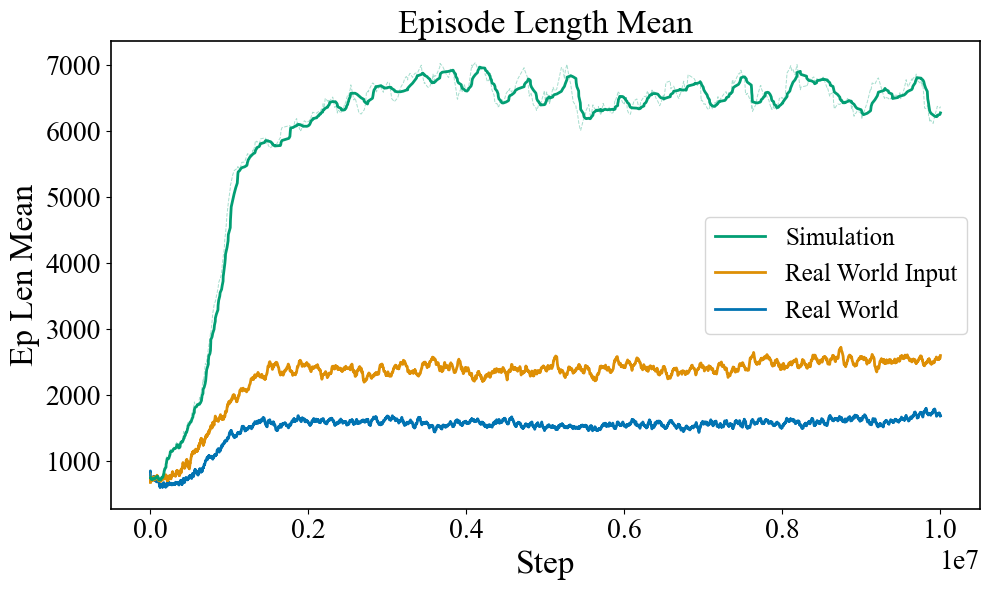

In [6]:
# keys = ["simulation", "simulation_with_real_world_input", "real_world"]
keys = ["real_world", "simulation_with_real_world_input", "simulation"]
legend_map = {
    "real_world": "Real World",
    "simulation_with_real_world_input": "Real World Input",
    "simulation": "Simulation",
}

data_ep_len = {key: read_rl_csv("ep_len_mean", key) for key in keys}

plot_rl_curves(
    data_ep_len,
    legend_map=legend_map,
    title="Episode Length Mean",
    x_label="Step",
    y_label="Ep Len Mean",
    figsize=(10, 6),
    window_size=10,
    save_path='three_system_len',
    is_legend=True,
)

## Episode Reward Mean (`ep_rew_mean`)

real csv file ep_rew_mean\real_world.csv
real csv file ep_rew_mean\simulation_with_real_world_input.csv
real csv file ep_rew_mean\simulation.csv
{'real_world': (0.00392156862745098, 0.45098039215686275, 0.6980392156862745), 'simulation_with_real_world_input': (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), 'simulation': (0.00784313725490196, 0.6196078431372549, 0.45098039215686275)}
key: real_world
key: simulation_with_real_world_input
key: simulation


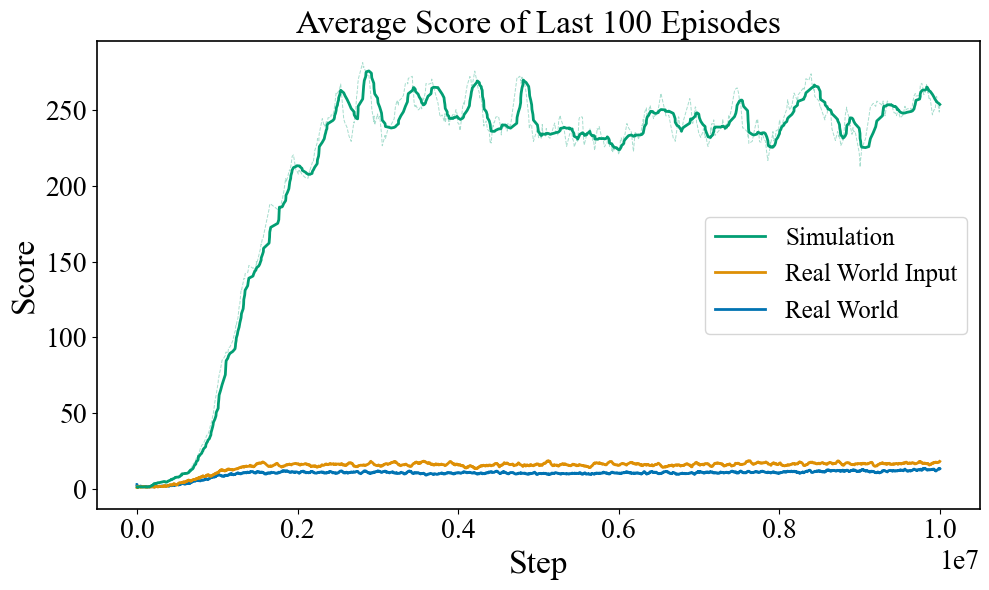

In [7]:
data_ep_rew = {key: read_rl_csv("ep_rew_mean", key) for key in keys}

plot_rl_curves(
    data_ep_rew,
    legend_map=legend_map,
    title="Average Score of Last 100 Episodes",
    x_label="Step",
    y_label="Score",
    figsize=(10, 6),
    window_size=10,
    save_path='three_system',
    is_legend=True,
)

real csv file ep_rew_mean\real_world.csv
real csv file ep_rew_mean\simulation_with_real_world_input.csv
{'real_world': (0.00392156862745098, 0.45098039215686275, 0.6980392156862745), 'simulation_with_real_world_input': (0.8705882352941177, 0.5607843137254902, 0.0196078431372549)}
key: real_world
key: simulation_with_real_world_input


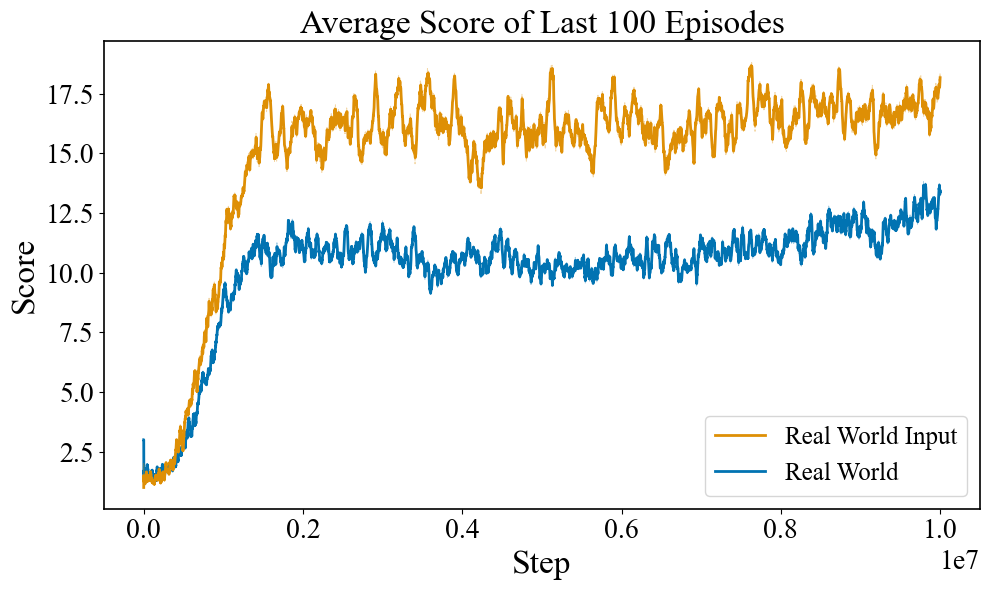

In [8]:
keys = ["real_world", "simulation_with_real_world_input", "simulation"]
legend_map = {
    "real_world": "Real World",
    "simulation_with_real_world_input": "Real World Input",
    "simulation": "Simulation",
}

keys = ["real_world", "simulation_with_real_world_input"]
data_ep_rew = {key: read_rl_csv("ep_rew_mean", key) for key in keys}

plot_rl_curves(
    data_ep_rew,
    legend_map=legend_map,
    # colors=["green", "dodgerblue"],
    title="Average Score of Last 100 Episodes",
    x_label="Step",
    y_label="Score",
    figsize=(10, 6),
    window_size=10,
    save_path='two_system',
    is_legend=True,
    skip_color=1,
)

## Top Score (`top_score`)

real csv file top_score\real_world.csv
real csv file top_score\simulation_with_real_world_input.csv
{'real_world': (0.00392156862745098, 0.45098039215686275, 0.6980392156862745), 'simulation_with_real_world_input': (0.8705882352941177, 0.5607843137254902, 0.0196078431372549)}
key: real_world
key: simulation_with_real_world_input


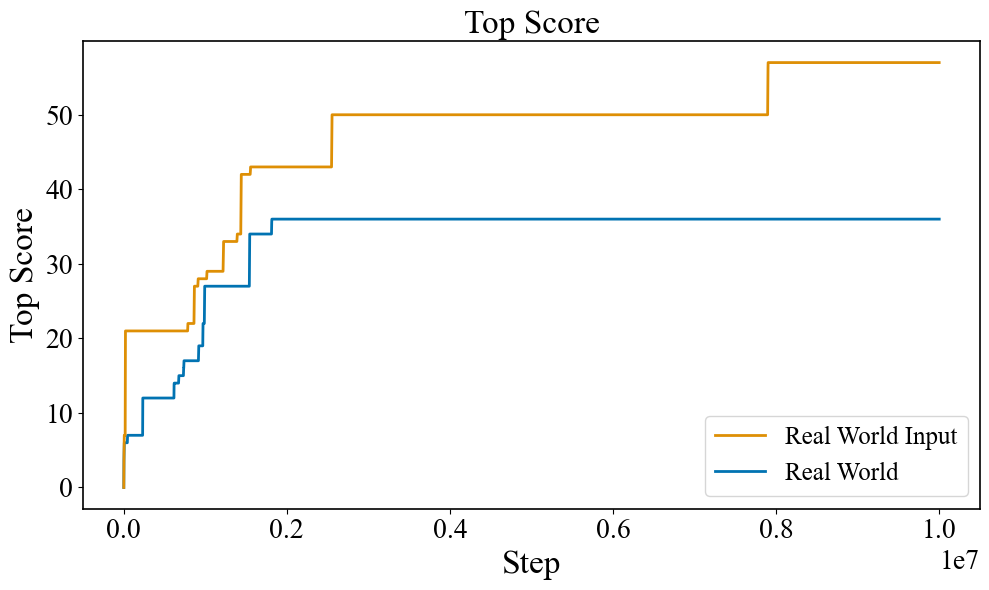

In [9]:
data_top_score = {key: read_rl_csv("top_score", key) for key in keys}

plot_rl_curves(
    data_top_score,
    legend_map=legend_map,
    title="Top Score",
    x_label="Step",
    y_label="Top Score",
    figsize=(10, 6),
    window_size=10,
    is_legend=True,
)

## Time Cost Comparison (Bar Chart)

Compare the **total wall-clock time consumed** by each setting across equal-length step intervals.

In [10]:
def read_rl_csv_full(metric: str, key: str, base_dir: str = ".") -> pd.DataFrame:
    """Read RL CSV with Wall time, Step, Value columns."""
    path = Path(base_dir) / metric / f"{key}.csv"
    df = pd.read_csv(path)
    return df[["Wall time", "Step", "Value"]].reset_index(drop=True)


def plot_time_cost_bar(
    metric: str = "ep_len_mean",
    keys: list = None,
    legend_map: dict = None,
    base_dir: str = ".",
    title: str = "Total Time Cost Comparison",
    # x_label: str = "Time Cost (s)",
    x_label: str = " ",
    y_label: str = " ",
    figsize: tuple = (8, 4),
    colors: list = None,
    save_path: str = None,
    dpi: int = 800,
    fontsize_title=None,
    fontsize_label=None,
    fontsize_tick=None,
    horizontal = True,
):
    """
    Plot a horizontal bar chart of total wall-clock time cost per setting.

    The total time is computed as:  max(Wall time) - min(Wall time).

    Args:
        metric:         which metric folder to read (only Wall time is used).
        keys:           list of file stems (settings).
        legend_map:     dict mapping key -> display label.
        base_dir:       root directory containing metric sub-folders.
        title:          chart title.
        x_label:        x-axis label.
        y_label:        y-axis label.
        figsize:        figure size (width, height) in inches.
        colors:         list of bar colours; if None, uses the style prop_cycle.
        save_path:      if given, saves the figure as <save_path>.pdf.
        dpi:            resolution for saved figure.
        fontsize_title: title font size (default: rcParams axes.titlesize).
        fontsize_label: axis label font size (default: rcParams axes.labelsize).
        fontsize_tick:  tick label font size (default: rcParams xtick.labelsize).
    """
    if keys is None:
        if horizontal:
            keys=["real_world", "simulation_with_real_world_input", "simulation"]
        else:
            keys=["simulation", "simulation_with_real_world_input", "real_world"]
            # keys=["real_world", "simulation_with_real_world_input", "simulation"]
        # keys = ["real_world", "simulation", "simulation_with_real_world_input"]
        # keys = ["real_world", "simulation_with_real_world_input", "simulation"]

    _title_fs = fontsize_title or plt.rcParams.get("axes.titlesize",  14)
    _label_fs = fontsize_label or plt.rcParams.get("axes.labelsize",  12)
    _tick_fs  = fontsize_tick  or plt.rcParams.get("xtick.labelsize", 10)

    # Load data and compute total wall-clock time per key
    total_times = {}
    for key in keys:
        print("key: ", key)
        df = read_rl_csv_full(metric, key, base_dir)
        total_times[key] = (df["Wall time"].max() - df["Wall time"].min())/3600/24

    # Resolve colors
    if colors is None:
        prop_cycle = plt.rcParams.get("axes.prop_cycle", None)
        # color_palette = sns.color_palette(color_palette, n_colors=len(algorithms)+1)
        colors = [c["color"] for c in prop_cycle] if prop_cycle else \
                 ["red", "green", "blue", "orange", "purple"]
        color_palette='colorblind'
        color_palette = sns.color_palette(color_palette, n_colors=len(keys))
        colors = dict(zip(keys, color_palette))
        print(colors)
    labels = [legend_map.get(k, k) if legend_map else k for k in keys]
    print(labels)

    values = [total_times[k] for k in keys]
    print(values)
    # bar_colors = [colors[i % len(colors)] for i in range(len(keys))]
    if horizontal:
        bar_colors = [colors[key] for key in keys]
    else:
        bar_colors = [colors[key] for key in keys][::-1]
    print(f"bar_colors: {bar_colors}")

    if horizontal:
        figsize = (5, 5)
        x_label = "Days"
    else:
        figsize = (5, 5)
        y_label = "Days"
    fig, ax = plt.subplots(figsize=figsize)
    # x = range(len(labels))
    if horizontal:
        bars = ax.barh(labels, values, height = 0.7, color=bar_colors, edgecolor="white", linewidth=0.5)
        # bars = ax.barh(labels, values, color=colors, edgecolor="white", linewidth=0.5)
        ax.set_xlim(right=max(values) * 1.1)
    else:
        bars = ax.bar(labels, values, width =0.7, color=bar_colors)
        ax.bar_label(bars, padding=3, fontsize=18, fmt="%.1f")
        ax.set_ylim(top=max(values) * 1.1)
        # ax.set_xticklabels(labels, rotation=90)
        # plt.xticks(rotation=90) 

    # ax.set_title(title, fontsize=_title_fs, pad=8)
    # ax.set_xlabel(x_label, fontsize=_label_fs)
    ax.set_ylabel(y_label, fontsize=_label_fs)
    # ax.tick_params(axis="x", labelsize=_tick_fs)
    ax.tick_params(axis="y", labelsize=_tick_fs)
    
    if save_path:
        fig.savefig(f"{save_path}.pdf", dpi=dpi, bbox_inches="tight")
    fig.tight_layout()
    plt.show()


key:  simulation
key:  simulation_with_real_world_input
key:  real_world
{'simulation': (0.00392156862745098, 0.45098039215686275, 0.6980392156862745), 'simulation_with_real_world_input': (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), 'real_world': (0.00784313725490196, 0.6196078431372549, 0.45098039215686275)}
['Sim', 'Real Input', 'Real']
[np.float64(1.4435714819282293), np.float64(8.158315157432247), np.float64(10.45353090359105)]
bar_colors: [(0.00784313725490196, 0.6196078431372549, 0.45098039215686275), (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), (0.00392156862745098, 0.45098039215686275, 0.6980392156862745)]


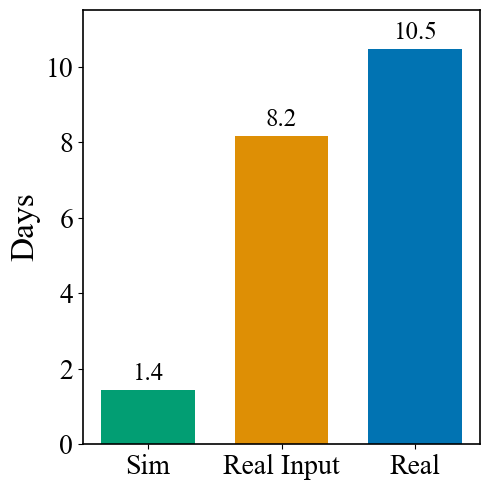

In [11]:
legend_map = {
    "real_world": "Real",
    "simulation_with_real_world_input": "Real Input",
    "simulation": "Sim",
}

plot_time_cost_bar(
    metric="ep_len_mean",
    # keys=["real_world", "simulation_with_real_world_input", "simulation"],
    legend_map=legend_map,
    base_dir=".",
    # colors=["red", "green", "dodgerblue"],
    title="Training Time",
    # title="Total Training Time for 10 Million Steps",
    # y_label="Days",
    # figsize=(4, 8),
    save_path="time_cost_bar",
    horizontal = False,
)

In [12]:
def plot_maximum_score_bar(
    metric: str = "ep_rew_mean",
    keys: list = None,
    legend_map: dict = None,
    base_dir: str = ".",
    title: str = "Total Time Cost Comparison",
    # x_label: str = "Time Cost (s)",
    x_label: str = " ",
    y_label: str = " ",
    figsize: tuple = (8, 4),
    colors: list = None,
    save_path: str = None,
    dpi: int = 800,
    fontsize_title=None,
    fontsize_label=None,
    fontsize_tick=None,
    horizontal = True,
):
    """
    Plot a horizontal bar chart of total wall-clock time cost per setting.

    The total time is computed as:  max(Wall time) - min(Wall time).

    Args:
        metric:         which metric folder to read (only Wall time is used).
        keys:           list of file stems (settings).
        legend_map:     dict mapping key -> display label.
        base_dir:       root directory containing metric sub-folders.
        title:          chart title.
        x_label:        x-axis label.
        y_label:        y-axis label.
        figsize:        figure size (width, height) in inches.
        colors:         list of bar colours; if None, uses the style prop_cycle.
        save_path:      if given, saves the figure as <save_path>.pdf.
        dpi:            resolution for saved figure.
        fontsize_title: title font size (default: rcParams axes.titlesize).
        fontsize_label: axis label font size (default: rcParams axes.labelsize).
        fontsize_tick:  tick label font size (default: rcParams xtick.labelsize).
    """
    if keys is None:
        if horizontal:
            keys=["real_world", "simulation_with_real_world_input", "simulation"]
        else:
            keys=["simulation", "simulation_with_real_world_input", "real_world"]
        # keys = ["real_world", "simulation", "simulation_with_real_world_input"]
        # keys = ["real_world", "simulation_with_real_world_input", "simulation"]

    _title_fs = fontsize_title or plt.rcParams.get("axes.titlesize",  14)
    _label_fs = fontsize_label or plt.rcParams.get("axes.labelsize",  12)
    _tick_fs  = fontsize_tick  or plt.rcParams.get("xtick.labelsize", 10)

    # Load data and compute total wall-clock time per key
    max_mean_score = {}
    for key in keys:
        print("key: ", key)
        df = read_rl_csv_full(metric, key, base_dir)
        max_mean_score[key] = df["Value"].max()

    # Resolve colors
    if colors is None:
        prop_cycle = plt.rcParams.get("axes.prop_cycle", None)
        # color_palette = sns.color_palette(color_palette, n_colors=len(algorithms)+1)
        colors = [c["color"] for c in prop_cycle] if prop_cycle else \
                 ["red", "green", "blue", "orange", "purple"]
        color_palette='colorblind'
        color_palette = sns.color_palette(color_palette, n_colors=len(keys))
        colors = dict(zip(keys, color_palette))
        print(colors)
    labels = [legend_map.get(k, k) if legend_map else k for k in keys]
    print(labels)
    values = [max_mean_score[k] for k in keys]
    # bar_colors = [colors[i % len(colors)] for i in range(len(keys))]
    bar_colors = [colors[key] for key in keys][::-1]
    print(f"bar_colors: {bar_colors}")

    if horizontal:
        figsize = (8, 4)
        x_label = "Scores"
    else:
        figsize = (5, 5)
        y_label = "Scores"
    fig, ax = plt.subplots(figsize=figsize)
    # x = range(len(labels))
    if horizontal:
        bars = ax.barh(labels, values, color=bar_colors, edgecolor="white", linewidth=0.5)
        # bars = ax.barh(labels, values, color=colors, edgecolor="white", linewidth=0.5)
        ax.set_xlim(right=max(values) * 1.1)
    else:
        bars = ax.bar(labels, values, width=0.7, color=bar_colors)
        ax.bar_label(bars, padding=3, fontsize=18, fmt="%.1f")
        ax.set_ylim(top=max(values) * 1.1)
        # ax.set_xticklabels(labels, rotation=90)
        # plt.xticks(rotation=90)



    # ax.set_title(title, fontsize=_title_fs, pad=8)
    # ax.set_xlabel(x_label, fontsize=_label_fs)
    ax.set_ylabel(y_label, fontsize=_label_fs)
    # ax.tick_params(axis="x", labelsize=_tick_fs)
    ax.tick_params(axis="y", labelsize=_tick_fs)
    plt.subplots_adjust(bottom=0.05)
    

    if save_path:
        fig.savefig(f"{save_path}.pdf", dpi=dpi, bbox_inches="tight")
    fig.tight_layout()
    plt.show()

key:  simulation
key:  simulation_with_real_world_input
key:  real_world
{'simulation': (0.00392156862745098, 0.45098039215686275, 0.6980392156862745), 'simulation_with_real_world_input': (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), 'real_world': (0.00784313725490196, 0.6196078431372549, 0.45098039215686275)}
['Sim', 'Real Input', 'Real']
bar_colors: [(0.00784313725490196, 0.6196078431372549, 0.45098039215686275), (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), (0.00392156862745098, 0.45098039215686275, 0.6980392156862745)]


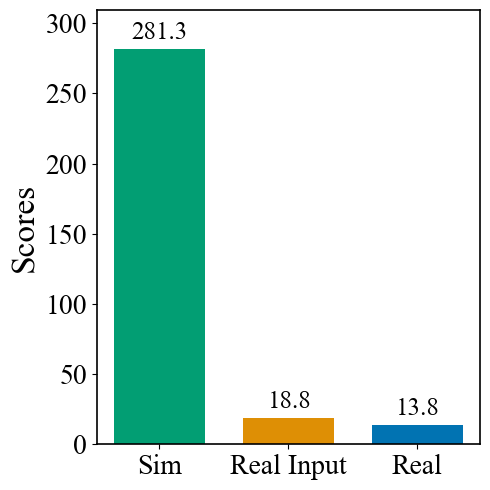

In [13]:
legend_map = {
    "real_world": "Real",
    "simulation_with_real_world_input": "Real Input",
    "simulation": "Sim",
}
plot_maximum_score_bar(
    metric="ep_rew_mean",
    # keys=["real_world", "simulation_with_real_world_input", "simulation"],
    legend_map=legend_map,
    base_dir=".",
    # colors=["red", "green", "dodgerblue"],
    title="Maximum Score",
    # y_label="Days",
    # figsize=(4, 8),
    save_path="max_score_bar",
    horizontal = False,
)

## Data Processing to find the best model

In [14]:
import time
import numpy as np

from evaluation.atari_data import get_human_normalized_score, get_env_id
from evaluation import library as rly
from evaluation import metrics
from evaluation import plot_utils

import tkinter as tk

import os

import gymnasium as gym

import argparse
from distutils.util import strtobool

import ale_py
gym.register_envs(ale_py)
gym.pprint_registry()

# import matplotlib
# import matplotlib.pyplot as plt

# # Use 'TkAgg', 'Qt5Agg', 'Qt4Agg', etc.
# # matplotlib.use('TkAgg')

# def setup_matplotlib_backend():
#     """Configure matplotlib backend based on environment"""

#     # Check if running in headless environment
#     if os.environ.get('DISPLAY') is None or os.environ.get('SSH_CONNECTION'):
#         print("Headless environment detected, using Agg backend")
#         matplotlib.use('Agg')
#         return 'headless'

#     # Try interactive backends in order of preference
#     interactive_backends = ['TkAgg', 'Qt5Agg', 'GTK3Agg']

#     for backend in interactive_backends:
#         try:
#             matplotlib.use(backend)
#             # Test if backend works
#             fig = plt.figure()
#             plt.close(fig)
#             print(f"Using interactive backend: {backend}")
#             return 'interactive'
#         except ImportError:
#             continue

#     # Fallback to Agg if no interactive backend works
#     print("No interactive backend available, falling back to Agg")
#     matplotlib.use('Agg')
#     return 'headless'

# matplotlib_backend = setup_matplotlib_backend()


===== classic_control =====
Acrobot-v1                  CartPole-v0                 CartPole-v1
MountainCar-v0              MountainCarContinuous-v0    Pendulum-v1
===== phys2d =====
phys2d/CartPole-v0          phys2d/CartPole-v1          phys2d/Pendulum-v0
===== box2d =====
BipedalWalker-v3            BipedalWalkerHardcore-v3    CarRacing-v3
LunarLander-v3              LunarLanderContinuous-v3
===== toy_text =====
Blackjack-v1                CliffWalking-v1             CliffWalkingSlippery-v1
FrozenLake-v1               FrozenLake8x8-v1            Taxi-v3
===== tabular =====
tabular/Blackjack-v0        tabular/CliffWalking-v0
===== None =====
Ant-v2                      Ant-v3                      GymV21Environment-v0
GymV26Environment-v0        HalfCheetah-v2              HalfCheetah-v3
Hopper-v2                   Hopper-v3                   Humanoid-v2
Humanoid-v3                 HumanoidStandup-v2          InvertedDoublePendulum-v2
InvertedPendulum-v2         Pusher-v2             

In [15]:
gym_id = "BreakoutNoFrameskip-v4"

In [16]:
env_id = get_env_id(gym_id)
print(f"env_id: {env_id}")

env_id: breakout


In [28]:
# files = ['./datalogs/3systems/breakout-data-dqn-model-c10_000_000.npz',
#          './datalogs/system1s0a/test_with_0s0a/breakout-data-dqn-model-9_000_000.npz']
            
# labels = ['real world system', 'real world input']

# files = ['C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result_20260517\\breakout-data-dqn-model-0_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result_20260517\\breakout-data-dqn-model-1_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result_20260517\\breakout-data-dqn-model-2_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result_20260517\\breakout-data-dqn-model-3_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result_20260517\\breakout-data-dqn-model-4_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result_20260517\\breakout-data-dqn-model-5_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result_20260517\\breakout-data-dqn-model-6_000_000.npz',
#          'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result_20260517\\breakout-data-dqn-model-7_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result_20260517\\breakout-data-dqn-model-8_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result_20260517\\breakout-data-dqn-model-9_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result_20260517\\breakout-data-dqn-model-10_000_000.npz'] # best

# files = ['C:\\GitHub\\data_and_plot\\10_66_28_74\\test_data_for_real_input_20260517\\breakout-data-dqn-model-0_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_data_for_real_input_20260517\\breakout-data-dqn-model-1_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_data_for_real_input_20260517\\breakout-data-dqn-model-2_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_data_for_real_input_20260517\\breakout-data-dqn-model-3_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_data_for_real_input_20260517\\breakout-data-dqn-model-4_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_data_for_real_input_20260517\\breakout-data-dqn-model-5_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_data_for_real_input_20260517\\breakout-data-dqn-model-6_000_000.npz', # best
#          'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_data_for_real_input_20260517\\breakout-data-dqn-model-7_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_data_for_real_input_20260517\\breakout-data-dqn-model-8_000_000.npz', # best
#          'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_data_for_real_input_20260517\\breakout-data-dqn-model-9_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_data_for_real_input_20260517\\breakout-data-dqn-model-10_000_000.npz']

# labels = ['0_000_000', '1_000_000', '2_000_000', '3_000_000', '4_000_000', '5_000_000', '6_000_000', '7_000_000', '8_000_000', '9_000_000', '10_000_000']

# files = ['C:\\GitHub\\data_and_plot\\10_66_28_74\\test_data_for_real_input_20260517\\breakout-data-dqn-model-6_000_000.npz',
#          'C:\\GitHub\\data_and_plot\\10_66_28_74\\simulation\\20260609\\breakout-data-dqn-model-_huggingface_1.npz',
#          'C:\\GitHub\\data_and_plot\\10_66_28_74\\simulation\\20260609_10\\breakout-data-dqn-model-_huggingface_2.npz']

# labels = ['6_000_000', 'huggingface_1', 'huggingface_2']

# files = ['C:\\GitHub\\data_and_plot\\10_66_28_74\\simulation\\20260609\\breakout-data-dqn-model-_huggingface_1.npz',
#          'C:\\GitHub\\data_and_plot\\10_66_28_74\\simulation\\20260609_10\\breakout-data-dqn-model-_huggingface_2.npz']

# labels = ['huggingface_1', 'huggingface_2']

files = ['C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260610\\breakout-data-dqn-model-0_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260610\\breakout-data-dqn-model-1_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260610\\breakout-data-dqn-model-2_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260610\\breakout-data-dqn-model-3_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260610\\breakout-data-dqn-model-4_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260610\\breakout-data-dqn-model-5_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260610\\breakout-data-dqn-model-6_000_000.npz',
         'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260610\\breakout-data-dqn-model-7_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260610\\breakout-data-dqn-model-8_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260610\\breakout-data-dqn-model-9_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260610\\breakout-data-dqn-model-10_000_000.npz']

labels = ['0_000_000', '1_000_000', '2_000_000', '3_000_000', '4_000_000', '5_000_000', '6_000_000', '7_000_000', '8_000_000', '9_000_000', '10_000_000']


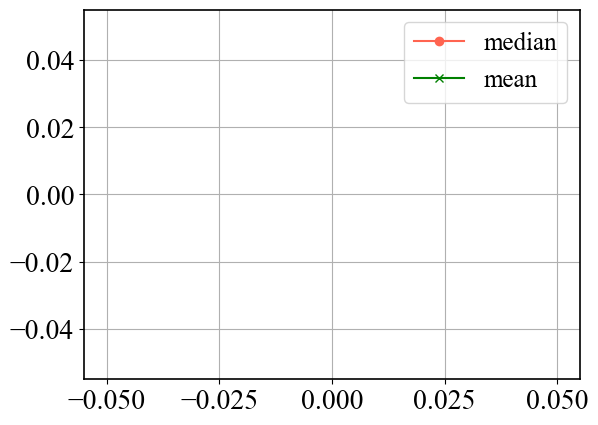

In [29]:
# plt.ion()  # Turn on interactive mode
fig1, ax1 = plt.subplots()
line1, = ax1.plot([], [], 'o-', label='median') 
line2, = ax1.plot([], [], 'x-', label='mean')

ax1.legend() 
ax1.grid(True)

plt.figure(fig1.number)
# plt.figure(fig3.number)

# plt.show(block=False)
x_data = []
y1_data = []
y2_data = []

In [30]:
f = 0

for file_path in files:
    
    f += 1
    
    # Load the existing data from the .npz file
    loaded_data = np.load(file_path)
    
    # Retrieve the existing array and datetime
    raw_scores = loaded_data['array']
    existing_array = np.array([get_human_normalized_score(env_id, score) for score in raw_scores])
    if len(existing_array) == 101:
        existing_array = existing_array[:-1]
        # existing_array = existing_array[1:]
    print(f"{file_path} Existing array: {existing_array}")
    csvfile = file_path.split('/')[-1].replace('.npz', '.csv')
    np.savetxt(csvfile, existing_array.reshape(-1, 1), delimiter=",")

    min_score = existing_array.min()
    max_score = existing_array.max()
    median = np.median(existing_array)
    mean = np.mean(existing_array)
    
    print("min: " + str(min_score) + " max: " + str(max_score) + " median: " + str(median) + " mean: " + str(mean))
    x_data.append(f)
    y1_data.append(median)
    y2_data.append(mean)
    plt.figure(fig1.number)

    line1.set_data(x_data, y1_data)
    line2.set_data(x_data, y2_data)
    ax1.set_xlim(0, max(x_data) + 1)
    ax1.set_ylim(0, max(max(y1_data), max(y2_data)) + 10)
    plt.draw()
    plt.pause(0.1)
    plt.show()
    
    if f == 1:
        array_for_dict = existing_array
    else:
        array_for_dict = np.vstack((array_for_dict, existing_array))

# Save the training progress plot after all test steps are completed
# fig1.savefig("training_progress_final.pdf", dpi=300, bbox_inches='tight')
# fig3.savefig("training_progress_final3.pdf", dpi=300, bbox_inches='tight')
# print("*"*5 + " Training progress plot saved as 'training_progress_final.pdf'")

# fig, ax1 = plt.subplots()


C:\GitHub\data_and_plot\wgzqrmn3\test_result\20260610\breakout-data-dqn-model-0_000_000.npz Existing array: [ 0.04513889 -0.02430556  0.01041667 -0.02430556  0.01041667 -0.05902778
  0.07986111  0.01041667  0.18402778 -0.05902778  0.01041667 -0.05902778
  0.11458333  0.01041667 -0.02430556  0.07986111 -0.05902778 -0.05902778
  0.04513889 -0.05902778 -0.05902778 -0.02430556  0.01041667 -0.05902778
  0.07986111  0.04513889 -0.02430556  0.01041667  0.04513889 -0.02430556
  0.01041667  0.01041667  0.04513889 -0.05902778 -0.02430556 -0.02430556
 -0.02430556  0.11458333  0.04513889 -0.02430556  0.01041667 -0.02430556
  0.01041667  0.01041667 -0.02430556 -0.05902778  0.01041667 -0.02430556
  0.07986111 -0.02430556 -0.05902778 -0.02430556 -0.05902778  0.14930556
  0.04513889 -0.05902778  0.01041667 -0.02430556 -0.05902778 -0.02430556
 -0.02430556 -0.05902778  0.01041667 -0.02430556  0.01041667 -0.02430556
 -0.05902778 -0.02430556  0.01041667  0.04513889 -0.02430556  0.01041667
  0.04513889 -0.

<Figure size 640x480 with 0 Axes>

C:\GitHub\data_and_plot\wgzqrmn3\test_result\20260610\breakout-data-dqn-model-1_000_000.npz Existing array: [0.32291667 0.32291667 0.42708333 0.14930556 0.18402778 0.32291667
 0.63541667 0.04513889 0.21875    0.32291667 0.25347222 0.32291667
 0.35763889 0.21875    0.21875    0.14930556 0.35763889 0.25347222
 0.21875    0.14930556 0.56597222 0.28819444 0.11458333 0.25347222
 0.49652778 0.07986111 0.18402778 0.25347222 0.14930556 0.25347222
 0.21875    0.67013889 0.35763889 0.25347222 0.35763889 0.25347222
 0.60069444 0.39236111 0.28819444 0.25347222 0.07986111 0.18402778
 0.39236111 0.14930556 0.25347222 0.32291667 0.07986111 0.25347222
 0.32291667 0.18402778 0.56597222 0.07986111 0.39236111 0.14930556
 0.07986111 0.18402778 0.35763889 0.18402778 0.25347222 0.25347222
 0.35763889 0.25347222 0.14930556 0.07986111 0.35763889 0.42708333
 0.49652778 0.28819444 0.42708333 0.07986111 0.21875    0.32291667
 0.18402778 0.25347222 0.18402778 0.42708333 0.25347222 0.67013889
 0.42708333 0.0451388

<Figure size 640x480 with 0 Axes>

C:\GitHub\data_and_plot\wgzqrmn3\test_result\20260610\breakout-data-dqn-model-2_000_000.npz Existing array: [0.25347222 0.35763889 0.39236111 0.49652778 0.32291667 0.21875
 0.32291667 0.35763889 0.18402778 0.39236111 0.07986111 0.35763889
 0.18402778 0.25347222 0.18402778 0.21875    0.21875    0.07986111
 0.25347222 0.42708333 0.56597222 0.11458333 0.53125    0.35763889
 0.21875    0.32291667 0.35763889 0.32291667 0.07986111 0.28819444
 0.42708333 0.60069444 0.25347222 0.42708333 0.46180556 0.25347222
 0.32291667 0.53125    0.14930556 0.46180556 0.42708333 0.18402778
 0.21875    0.32291667 0.35763889 0.11458333 0.49652778 0.49652778
 0.67013889 0.35763889 0.28819444 0.21875    0.28819444 0.42708333
 0.56597222 0.39236111 0.46180556 0.39236111 0.32291667 0.39236111
 0.53125    0.53125    0.39236111 0.39236111 0.32291667 0.25347222
 0.32291667 0.39236111 0.46180556 0.21875    0.25347222 0.21875
 0.25347222 0.39236111 0.39236111 0.25347222 0.46180556 0.28819444
 0.35763889 0.60069444 0.21

...

<Figure size 640x480 with 0 Axes>

C:\GitHub\data_and_plot\wgzqrmn3\test_result\20260610\breakout-data-dqn-model-9_000_000.npz Existing array: [0.32291667 0.25347222 0.35763889 0.04513889 0.28819444 0.07986111
 0.25347222 0.42708333 0.32291667 0.28819444 0.42708333 0.18402778
 0.35763889 0.35763889 0.32291667 0.01041667 0.14930556 0.39236111
 0.28819444 0.28819444 0.21875    0.35763889 0.28819444 0.35763889
 0.14930556 0.25347222 0.28819444 0.18402778 0.32291667 0.11458333
 0.04513889 0.21875    0.21875    0.42708333 0.67013889 0.35763889
 0.21875    0.18402778 0.32291667 0.32291667 0.32291667 0.35763889
 0.49652778 0.21875    0.14930556 0.91319444 0.25347222 0.39236111
 0.14930556 0.39236111 0.14930556 0.42708333 0.21875    0.14930556
 0.42708333 0.18402778 0.32291667 0.18402778 0.42708333 0.18402778
 0.25347222 0.60069444 0.28819444 0.73958333 0.21875    0.21875
 0.46180556 0.32291667 0.21875    0.14930556 0.32291667 0.28819444
 0.11458333 0.46180556 0.25347222 0.28819444 0.32291667 0.32291667
 0.18402778 0.28819444 0

<Figure size 640x480 with 0 Axes>

C:\GitHub\data_and_plot\wgzqrmn3\test_result\20260610\breakout-data-dqn-model-10_000_000.npz Existing array: [0.25347222 0.14930556 0.49652778 0.32291667 0.35763889 0.35763889
 0.56597222 0.21875    0.11458333 0.25347222 0.35763889 0.28819444
 0.42708333 0.32291667 0.28819444 0.35763889 0.49652778 0.21875
 0.25347222 0.63541667 0.35763889 0.11458333 0.39236111 0.46180556
 0.49652778 0.60069444 0.28819444 0.60069444 0.07986111 0.63541667
 0.39236111 0.42708333 0.32291667 0.56597222 0.46180556 0.63541667
 0.49652778 0.21875    0.18402778 0.35763889 0.11458333 0.25347222
 0.91319444 0.18402778 0.35763889 0.49652778 0.46180556 0.35763889
 0.28819444 0.39236111 0.42708333 0.49652778 0.56597222 0.21875
 0.39236111 0.18402778 0.35763889 0.32291667 0.56597222 0.21875
 0.70486111 0.39236111 0.80902778 0.53125    0.28819444 0.18402778
 0.18402778 0.42708333 0.14930556 0.46180556 0.35763889 0.70486111
 0.46180556 0.28819444 0.46180556 0.32291667 0.49652778 0.67013889
 0.42708333 0.39236111 0.4965

<Figure size 640x480 with 0 Axes>

C:\Users\rongp\AppData\Local\Temp\ipykernel_77872\2254188213.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(list(array_for_dict), labels=labels)


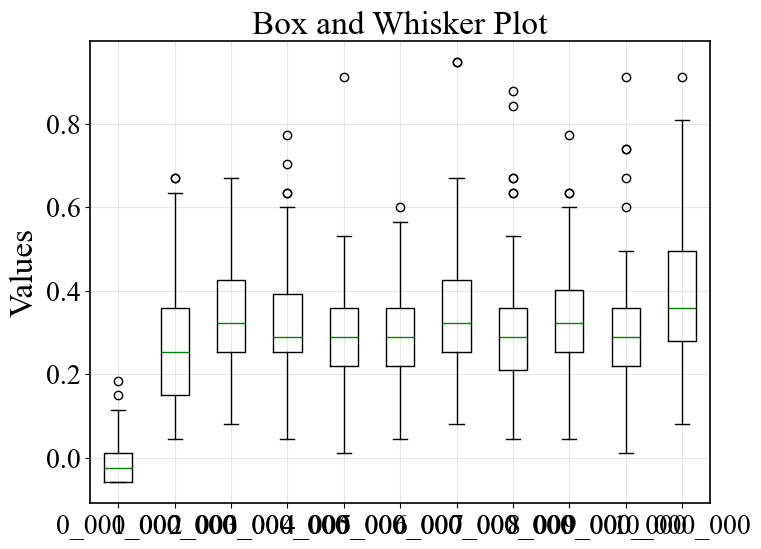

In [31]:
plt.figure(figsize=(8, 6))
bp = plt.boxplot(list(array_for_dict), labels=labels)
plt.ylabel('Values')
plt.title('Box and Whisker Plot')
plt.grid(True, alpha=0.3)
plt.draw()
 
plt.pause(0.1)
plt.show()

In [32]:
hns_dict = {}

for i in range(min(len(labels), array_for_dict.shape[0])):
    # The evaluation library expects 2D arrays: [num_runs, num_tasks]
    # array_for_dict[i] is 1D (101 scores from 101 test episodes)
    # We need to reshape it to 2D: [101 runs, 1 task] for single-task evaluation
    # print(f"Original shape of array_for_dict[{i}]: {array_for_dict[i].shape}")
    scores_2d = np.array(array_for_dict[i]).reshape(-1, 1)  # Convert 1D to 2D
    # print(f"Reshaped scores_2d for {labels[i]}: {scores_2d.shape}")
    # scores_2d = np.array(array_for_dict[i]).reshape(1, -1)  # Convert 1D to 2D
    hns_dict[labels[i]] = scores_2d
    # hns_dict[labels[i]] = array_for_dict[i]

# for key, value in hns_dict.items():
#     print(f"{key}: ")
#     print(f"{value}")

aggregate_scores 0_000_000: 
[-0.02430556 -0.01041667 -0.00381944  1.00381944]
aggregate_scores 1_000_000: 
[0.25347222 0.24583333 0.26284722 0.73715278]
aggregate_scores 2_000_000: 
[0.32291667 0.33958333 0.34131944 0.65868056]
aggregate_scores 3_000_000: 
[0.28819444 0.30277778 0.32326389 0.67673611]
aggregate_scores 4_000_000: 
[0.28819444 0.28680556 0.296875   0.703125  ]
aggregate_scores 5_000_000: 
[0.28819444 0.28819444 0.29513889 0.70486111]
aggregate_scores 6_000_000: 
[0.32291667 0.32291667 0.34618056 0.65381944]
aggregate_scores 7_000_000: 
[0.28819444 0.28194444 0.30694444 0.69305556]
aggregate_scores 8_000_000: 
[0.32291667 0.33055556 0.34340278 0.65659722]
aggregate_scores 9_000_000: 
[0.28819444 0.29097222 0.30034722 0.69965278]
aggregate_scores 10_000_000: 
[0.35763889 0.37430556 0.38715278 0.61284722]
aggregate_score_cis 0_000_000: 
[[-2.43055556e-02 -2.15277778e-02 -1.35416667e-02  9.93750000e-01]
 [ 1.04166667e-02 -6.94444444e-04  6.25000000e-03  1.01354167e+00]]
agg

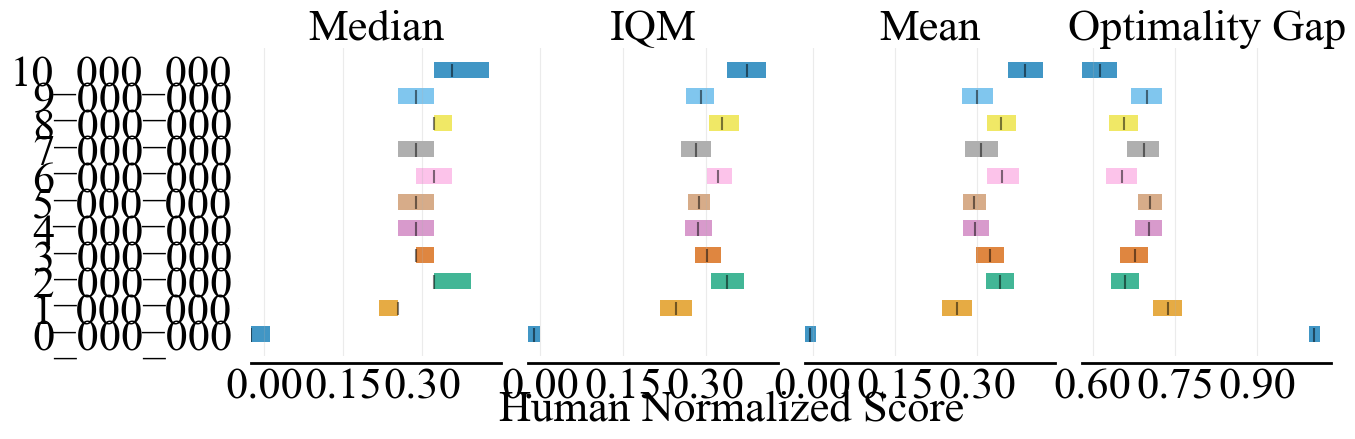

In [33]:
aggregate_func = lambda x: np.array([
    metrics.aggregate_median(x),
    metrics.aggregate_iqm(x),
    metrics.aggregate_mean(x),
    metrics.aggregate_optimality_gap(x)])
    
aggregate_scores, aggregate_score_cis = rly.get_interval_estimates(hns_dict, aggregate_func, reps=50000)

for key, value in aggregate_scores.items():
    print(f"aggregate_scores {key}: ")
    print(f"{value}")

for key, value in aggregate_score_cis.items():
    print(f"aggregate_score_cis {key}: ")
    print(f"{value}")        

# Use only the algorithms that actually have data
available_algorithms = list(hns_dict.keys())
print("*"*5 + " Available algorithms for plotting: ", available_algorithms)

fig2, ax2 = plot_utils.plot_interval_estimates(
    aggregate_scores,
    aggregate_score_cis,
    metric_names=['Median', 'IQM', 'Mean', 'Optimality Gap'],
    algorithms=available_algorithms,
    xlabel_y_coordinate=-0.05,
    xlabel='Human Normalized Score')

fig2.set_size_inches(12, 4)

plt.figure(fig2.number)

fig2.savefig("hns_all_data.pdf", dpi=300, bbox_inches='tight')

plt.pause(0.1)
plt.show()

aggregate_scores 0_000_000: 
[-0.02430556]
aggregate_scores 1_000_000: 
[0.25347222]
aggregate_scores 2_000_000: 
[0.32291667]
aggregate_scores 3_000_000: 
[0.28819444]
aggregate_scores 4_000_000: 
[0.28819444]
aggregate_scores 5_000_000: 
[0.28819444]
aggregate_scores 6_000_000: 
[0.32291667]
aggregate_scores 7_000_000: 
[0.28819444]
aggregate_scores 8_000_000: 
[0.32291667]
aggregate_scores 9_000_000: 
[0.28819444]
aggregate_scores 10_000_000: 
[0.35763889]
aggregate_score_cis 0_000_000: 
[[-0.02430556]
 [ 0.01041667]]
aggregate_score_cis 1_000_000: 
[[0.21875   ]
 [0.25347222]]
aggregate_score_cis 2_000_000: 
[[0.32291667]
 [0.39236111]]
aggregate_score_cis 3_000_000: 
[[0.28819444]
 [0.32291667]]
aggregate_score_cis 4_000_000: 
[[0.25347222]
 [0.32291667]]
aggregate_score_cis 5_000_000: 
[[0.25347222]
 [0.32291667]]
aggregate_score_cis 6_000_000: 
[[0.28819444]
 [0.35763889]]
aggregate_score_cis 7_000_000: 
[[0.25347222]
 [0.32291667]]
aggregate_score_cis 8_000_000: 
[[0.32291667]


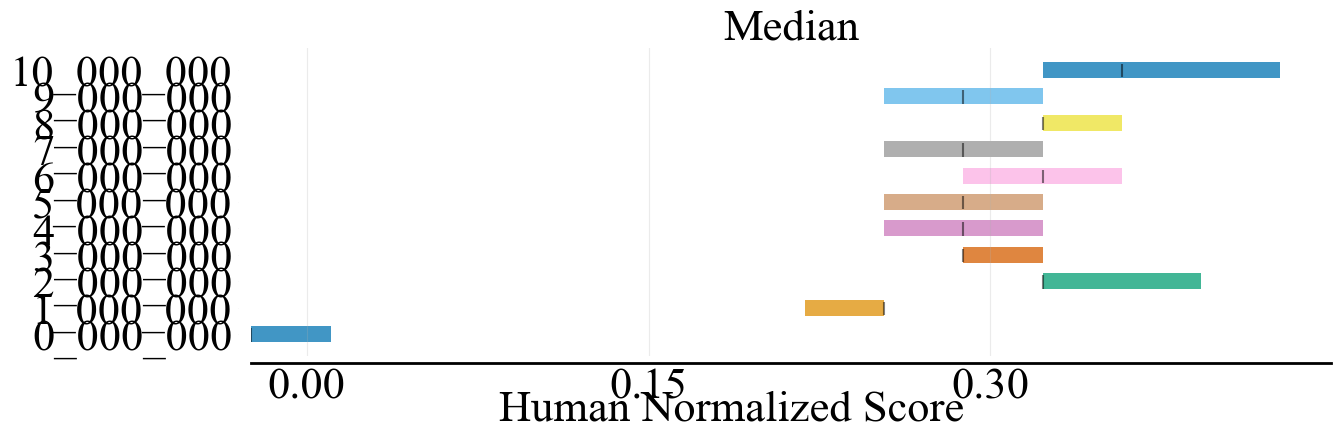

In [34]:
aggregate_func = lambda x: np.array([
    metrics.aggregate_median(x)])

aggregate_scores, aggregate_score_cis = rly.get_interval_estimates(hns_dict, aggregate_func, reps=50000)

for key, value in aggregate_scores.items():
    print(f"aggregate_scores {key}: ")
    print(f"{value}")

for key, value in aggregate_score_cis.items():
    print(f"aggregate_score_cis {key}: ")
    print(f"{value}")        

# Use only the algorithms that actually have data
available_algorithms = list(hns_dict.keys())
print("*"*5 + " Available algorithms for plotting: ", available_algorithms)

fig3, ax3 = plot_utils.plot_interval_estimates(
    aggregate_scores,
    aggregate_score_cis,
    metric_names=['Median'],
    algorithms=available_algorithms,
    subfigure_width=3.4,
    row_height=1.0,
    xlabel_y_coordinate=-0.05,
    xlabel='Human Normalized Score')

fig3.set_size_inches(12, 4)

plt.figure(fig3.number)

fig3.savefig("hns_median_all_data.pdf", dpi=300, bbox_inches='tight')

plt.pause(0.1)
plt.show()

aggregate_scores 0_000_000: 
[-0.00381944]
aggregate_scores 1_000_000: 
[0.26284722]
aggregate_scores 2_000_000: 
[0.34131944]
aggregate_scores 3_000_000: 
[0.32326389]
aggregate_scores 4_000_000: 
[0.296875]
aggregate_scores 5_000_000: 
[0.29513889]
aggregate_scores 6_000_000: 
[0.34618056]
aggregate_scores 7_000_000: 
[0.30694444]
aggregate_scores 8_000_000: 
[0.34340278]
aggregate_scores 9_000_000: 
[0.30034722]
aggregate_scores 10_000_000: 
[0.38715278]
aggregate_score_cis 0_000_000: 
[[-0.01319444]
 [ 0.00625   ]]
aggregate_score_cis 1_000_000: 
[[0.23645833]
 [0.29027778]]
aggregate_score_cis 2_000_000: 
[[0.315625  ]
 [0.36736111]]
aggregate_score_cis 3_000_000: 
[[0.29826389]
 [0.34965278]]
aggregate_score_cis 4_000_000: 
[[0.27361111]
 [0.32118056]]
aggregate_score_cis 5_000_000: 
[[0.27430556]
 [0.31631944]]
aggregate_score_cis 6_000_000: 
[[0.31875   ]
 [0.37604167]]
aggregate_score_cis 7_000_000: 
[[0.27881944]
 [0.33715278]]
aggregate_score_cis 8_000_000: 
[[0.31701389]
 [

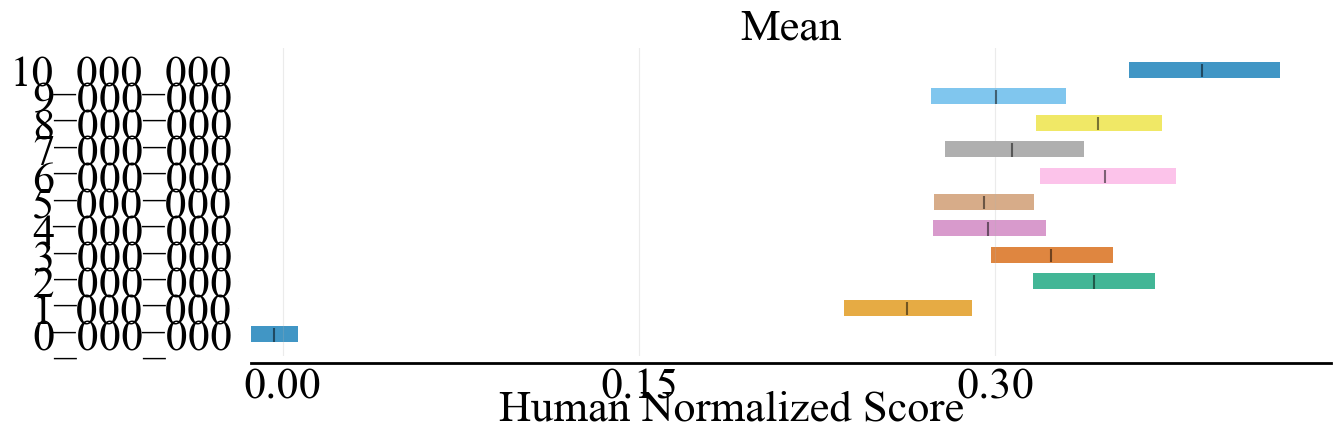

In [35]:
aggregate_func = lambda x: np.array([
    metrics.aggregate_mean(x)])

aggregate_scores, aggregate_score_cis = rly.get_interval_estimates(hns_dict, aggregate_func, reps=50000)

for key, value in aggregate_scores.items():
    print(f"aggregate_scores {key}: ")
    print(f"{value}")

for key, value in aggregate_score_cis.items():
    print(f"aggregate_score_cis {key}: ")
    print(f"{value}")        

# Use only the algorithms that actually have data
available_algorithms = list(hns_dict.keys())
print("*"*5 + " Available algorithms for plotting: ", available_algorithms)

fig4, ax4 = plot_utils.plot_interval_estimates(
    aggregate_scores,
    aggregate_score_cis,
    metric_names=['Mean'],
    algorithms=available_algorithms,
    subfigure_width=3.4,
    row_height=1.0,
    xlabel_y_coordinate=-0.05,
    xlabel='Human Normalized Score')

fig4.set_size_inches(12, 4)

plt.figure(fig4.number)

fig4.savefig("hns_mean_all_data.pdf", dpi=300, bbox_inches='tight')

plt.pause(0.1)
plt.show()

aggregate_scores 0_000_000: 
[-0.01041667]
aggregate_scores 1_000_000: 
[0.24583333]
aggregate_scores 2_000_000: 
[0.33958333]
aggregate_scores 3_000_000: 
[0.30277778]
aggregate_scores 4_000_000: 
[0.28680556]
aggregate_scores 5_000_000: 
[0.28819444]
aggregate_scores 6_000_000: 
[0.32291667]
aggregate_scores 7_000_000: 
[0.28194444]
aggregate_scores 8_000_000: 
[0.33055556]
aggregate_scores 9_000_000: 
[0.29097222]
aggregate_scores 10_000_000: 
[0.37430556]
aggregate_score_cis 0_000_000: 
[[-0.02152778]
 [-0.00069444]]
aggregate_score_cis 1_000_000: 
[[0.21736111]
 [0.275     ]]
aggregate_score_cis 2_000_000: 
[[0.30972222]
 [0.36944444]]
aggregate_score_cis 3_000_000: 
[[0.28125   ]
 [0.32777778]]
aggregate_score_cis 4_000_000: 
[[0.26180556]
 [0.31180556]]
aggregate_score_cis 5_000_000: 
[[0.26875   ]
 [0.30833333]]
aggregate_score_cis 6_000_000: 
[[0.30208333]
 [0.34861111]]
aggregate_score_cis 7_000_000: 
[[0.25555556]
 [0.30902778]]
aggregate_score_cis 8_000_000: 
[[0.30555556]


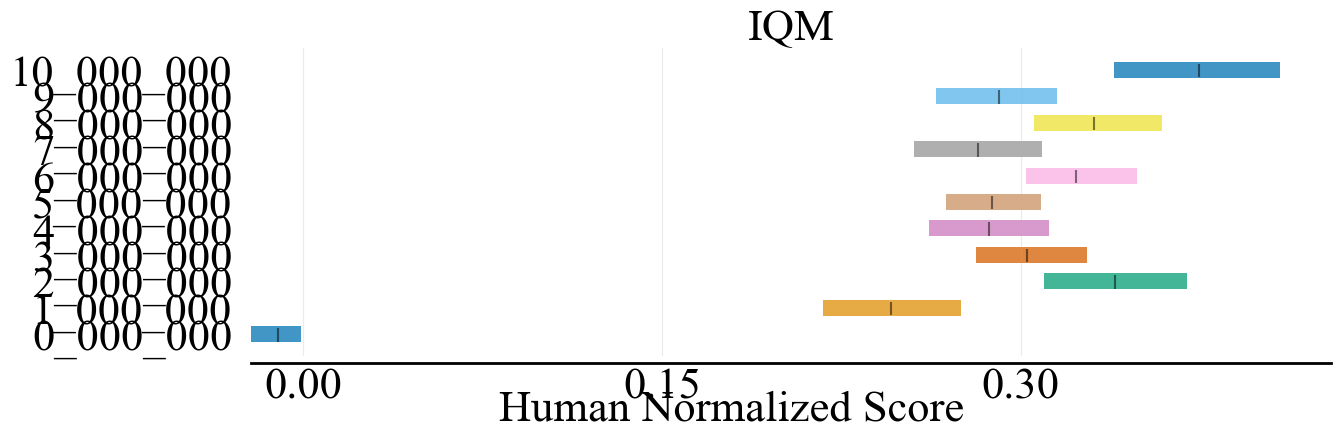

In [36]:
aggregate_func = lambda x: np.array([
    metrics.aggregate_iqm(x)])

aggregate_scores, aggregate_score_cis = rly.get_interval_estimates(hns_dict, aggregate_func, reps=50000)

for key, value in aggregate_scores.items():
    print(f"aggregate_scores {key}: ")
    print(f"{value}")

for key, value in aggregate_score_cis.items():
    print(f"aggregate_score_cis {key}: ")
    print(f"{value}")        

# Use only the algorithms that actually have data
available_algorithms = list(hns_dict.keys())
print("*"*5 + " Available algorithms for plotting: ", available_algorithms)

fig5, ax5 = plot_utils.plot_interval_estimates(
    aggregate_scores,
    aggregate_score_cis,
    metric_names=['IQM'],
    algorithms=available_algorithms,
    subfigure_width=3.4,
    row_height=1.0,
    xlabel_y_coordinate=-0.05,
    xlabel='Human Normalized Score')

fig5.set_size_inches(12, 4)

plt.figure(fig5.number)

fig5.savefig("hns_iqm_all_data.pdf", dpi=300, bbox_inches='tight')

plt.pause(0.1)
plt.show()

aggregate_scores 0_000_000: 
[1.00381944]
aggregate_scores 1_000_000: 
[0.73715278]
aggregate_scores 2_000_000: 
[0.65868056]
aggregate_scores 3_000_000: 
[0.67673611]
aggregate_scores 4_000_000: 
[0.703125]
aggregate_scores 5_000_000: 
[0.70486111]
aggregate_scores 6_000_000: 
[0.65381944]
aggregate_scores 7_000_000: 
[0.69305556]
aggregate_scores 8_000_000: 
[0.65659722]
aggregate_scores 9_000_000: 
[0.69965278]
aggregate_scores 10_000_000: 
[0.61284722]
aggregate_score_cis 0_000_000: 
[[0.99375   ]
 [1.01319444]]
aggregate_score_cis 1_000_000: 
[[0.709375  ]
 [0.76354167]]
aggregate_score_cis 2_000_000: 
[[0.63263889]
 [0.684375  ]]
aggregate_score_cis 3_000_000: 
[[0.65034722]
 [0.70173611]]
aggregate_score_cis 4_000_000: 
[[0.67847222]
 [0.72604167]]
aggregate_score_cis 5_000_000: 
[[0.68368056]
 [0.72569444]]
aggregate_score_cis 6_000_000: 
[[0.62395833]
 [0.68125   ]]
aggregate_score_cis 7_000_000: 
[[0.6625    ]
 [0.72152778]]
aggregate_score_cis 8_000_000: 
[[0.62951389]
 [0.6

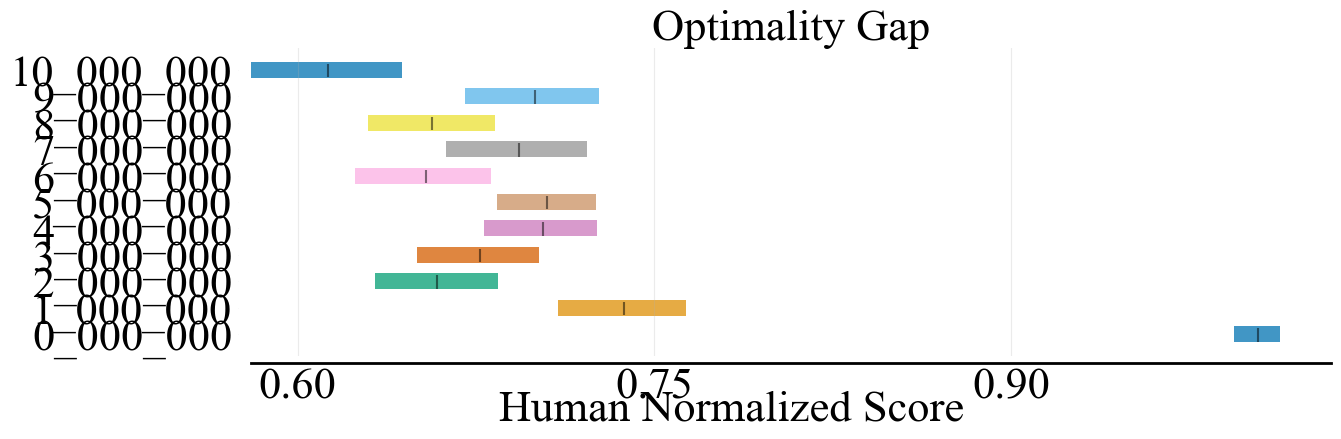

In [37]:
aggregate_func = lambda x: np.array([
    metrics.aggregate_optimality_gap(x)])

aggregate_scores, aggregate_score_cis = rly.get_interval_estimates(hns_dict, aggregate_func, reps=50000)

for key, value in aggregate_scores.items():
    print(f"aggregate_scores {key}: ")
    print(f"{value}")

for key, value in aggregate_score_cis.items():
    print(f"aggregate_score_cis {key}: ")
    print(f"{value}")        

# Use only the algorithms that actually have data
available_algorithms = list(hns_dict.keys())
print("*"*5 + " Available algorithms for plotting: ", available_algorithms)

fig6, ax6 = plot_utils.plot_interval_estimates(
    aggregate_scores,
    aggregate_score_cis,
    metric_names=['Optimality Gap'],
    algorithms=available_algorithms,
    subfigure_width=3.4,
    row_height=1.0,
    xlabel_y_coordinate=-0.05,
    xlabel='Human Normalized Score')

fig6.set_size_inches(12, 4)

plt.figure(fig6.number)

fig6.savefig("hns_optimality_gap_all_data.pdf", dpi=300, bbox_inches='tight')

plt.pause(0.1)
plt.show()

In [38]:
files = ['C:\\GitHub\\data_and_plot\\10_66_28_74\\test_result\\20260517\\breakout-data-dqn-model-0_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_result\\20260517\\breakout-data-dqn-model-1_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_result\\20260517\\breakout-data-dqn-model-2_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_result\\20260517\\breakout-data-dqn-model-3_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_result\\20260517\\breakout-data-dqn-model-4_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_result\\20260517\\breakout-data-dqn-model-5_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_result\\20260517\\breakout-data-dqn-model-6_000_000.npz',
         'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_result\\20260517\\breakout-data-dqn-model-7_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_result\\20260517\\breakout-data-dqn-model-8_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_result\\20260517\\breakout-data-dqn-model-9_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_result\\20260517\\breakout-data-dqn-model-10_000_000.npz']

labels = ['0_000_000', '1_000_000', '2_000_000', '3_000_000', '4_000_000', '5_000_000', '6_000_000', '7_000_000', '8_000_000', '9_000_000', '10_000_000']


In [39]:
f = 0

for file_path in files:
    
    f += 1
    
    # Load the existing data from the .npz file
    loaded_data = np.load(file_path)
    
    # Retrieve the existing array and datetime
    raw_scores = loaded_data['array']
    existing_array = np.array([get_human_normalized_score(env_id, score) for score in raw_scores])
    if len(existing_array) == 101:
        existing_array = existing_array[:-1]
        # existing_array = existing_array[1:]
    print(f"{file_path} Existing array: {existing_array}")
    csvfile = file_path.split('/')[-1].replace('.npz', '.csv')
    np.savetxt(csvfile, existing_array.reshape(-1, 1), delimiter=",")

    min_score = existing_array.min()
    max_score = existing_array.max()
    median = np.median(existing_array)
    mean = np.mean(existing_array)
    
    print("min: " + str(min_score) + " max: " + str(max_score) + " median: " + str(median) + " mean: " + str(mean))

    if f == 1:
        array_for_dict = existing_array
    else:
        array_for_dict = np.vstack((array_for_dict, existing_array))


C:\GitHub\data_and_plot\10_66_28_74\test_result\20260517\breakout-data-dqn-model-0_000_000.npz Existing array: [-0.02430556  0.01041667  0.04513889  0.07986111 -0.05902778  0.04513889
  0.04513889  0.18402778  0.04513889 -0.02430556 -0.02430556  0.18402778
 -0.05902778  0.07986111 -0.05902778  0.21875     0.11458333  0.07986111
  0.04513889  0.01041667 -0.05902778  0.01041667  0.04513889  0.07986111
  0.11458333 -0.02430556 -0.02430556  0.11458333 -0.02430556  0.04513889
  0.11458333 -0.05902778 -0.02430556  0.07986111  0.01041667  0.01041667
  0.07986111  0.18402778  0.04513889  0.25347222  0.01041667 -0.02430556
 -0.05902778  0.04513889  0.04513889 -0.05902778  0.01041667 -0.05902778
 -0.05902778 -0.05902778 -0.02430556  0.01041667  0.07986111  0.07986111
 -0.05902778  0.07986111  0.07986111  0.07986111 -0.02430556  0.04513889
  0.11458333 -0.02430556  0.04513889 -0.02430556  0.11458333  0.42708333
  0.11458333  0.04513889  0.07986111  0.01041667  0.18402778 -0.02430556
  0.07986111 

C:\Users\rongp\AppData\Local\Temp\ipykernel_77872\2254188213.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(list(array_for_dict), labels=labels)


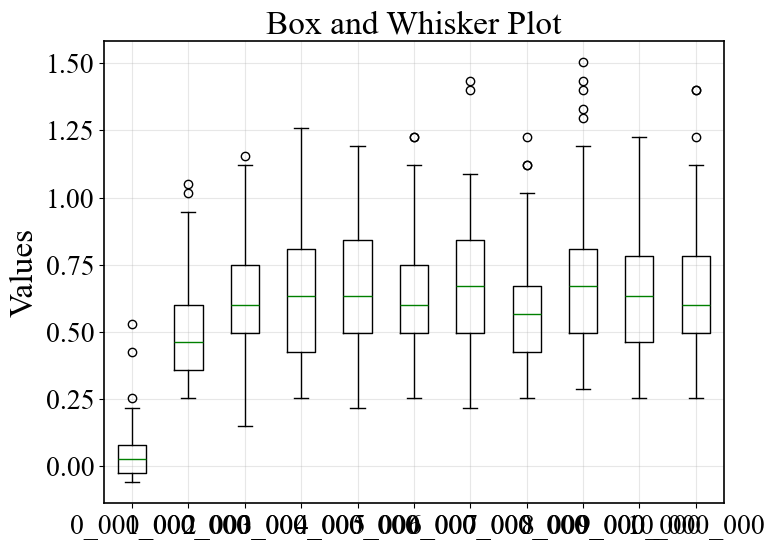

In [40]:
plt.figure(figsize=(8, 6))
bp = plt.boxplot(list(array_for_dict), labels=labels)
plt.ylabel('Values')
plt.title('Box and Whisker Plot')
plt.grid(True, alpha=0.3)
plt.draw()
 
plt.pause(0.1)
plt.show()

In [41]:
hns_dict = {}

for i in range(min(len(labels), array_for_dict.shape[0])):
    # The evaluation library expects 2D arrays: [num_runs, num_tasks]
    # array_for_dict[i] is 1D (101 scores from 101 test episodes)
    # We need to reshape it to 2D: [101 runs, 1 task] for single-task evaluation
    # print(f"Original shape of array_for_dict[{i}]: {array_for_dict[i].shape}")
    scores_2d = np.array(array_for_dict[i]).reshape(-1, 1)  # Convert 1D to 2D
    # print(f"Reshaped scores_2d for {labels[i]}: {scores_2d.shape}")
    # scores_2d = np.array(array_for_dict[i]).reshape(1, -1)  # Convert 1D to 2D
    hns_dict[labels[i]] = scores_2d
    # hns_dict[labels[i]] = array_for_dict[i]

# for key, value in hns_dict.items():
#     print(f"{key}: ")
#     print(f"{value}")

aggregate_scores 0_000_000: 
[0.02777778 0.03055556 0.04236111 0.95763889]
aggregate_scores 1_000_000: 
[0.46180556 0.47638889 0.50694444 0.49375   ]
aggregate_scores 2_000_000: 
[0.60069444 0.61319444 0.621875   0.38194444]
aggregate_scores 3_000_000: 
[0.63541667 0.61111111 0.63472222 0.37569444]
aggregate_scores 4_000_000: 
[0.63541667 0.65625    0.66666667 0.33993056]
aggregate_scores 5_000_000: 
[0.60069444 0.60833333 0.64097222 0.36770833]
aggregate_scores 6_000_000: 
[0.67013889 0.65555556 0.67881944 0.3328125 ]
aggregate_scores 7_000_000: 
[0.56597222 0.55416667 0.57465278 0.43020833]
aggregate_scores 8_000_000: 
[0.67013889 0.65138889 0.69097222 0.33489583]
aggregate_scores 9_000_000: 
[0.63541667 0.62777778 0.65381944 0.35815972]
aggregate_scores 10_000_000: 
[0.60069444 0.61111111 0.65       0.36180556]
aggregate_score_cis 0_000_000: 
[[0.01041667 0.01319444 0.025      0.93854167]
 [0.04513889 0.04722222 0.06145833 0.975     ]]
aggregate_score_cis 1_000_000: 
[[0.42708333 0.

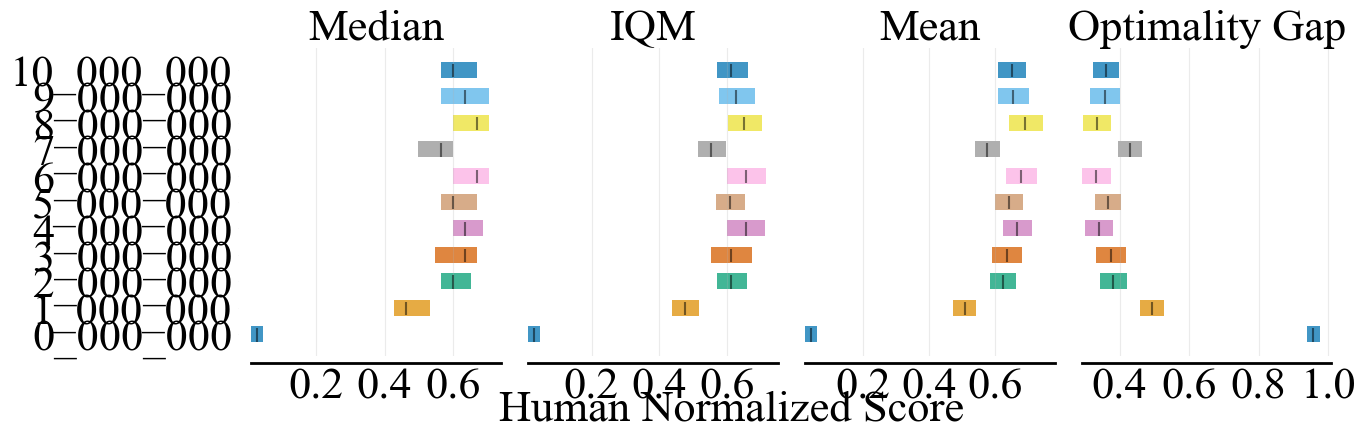

In [42]:
aggregate_func = lambda x: np.array([
    metrics.aggregate_median(x),
    metrics.aggregate_iqm(x),
    metrics.aggregate_mean(x),
    metrics.aggregate_optimality_gap(x)])
    
aggregate_scores, aggregate_score_cis = rly.get_interval_estimates(hns_dict, aggregate_func, reps=50000)

for key, value in aggregate_scores.items():
    print(f"aggregate_scores {key}: ")
    print(f"{value}")

for key, value in aggregate_score_cis.items():
    print(f"aggregate_score_cis {key}: ")
    print(f"{value}")        

# Use only the algorithms that actually have data
available_algorithms = list(hns_dict.keys())
print("*"*5 + " Available algorithms for plotting: ", available_algorithms)

fig2, ax2 = plot_utils.plot_interval_estimates(
    aggregate_scores,
    aggregate_score_cis,
    metric_names=['Median', 'IQM', 'Mean', 'Optimality Gap'],
    algorithms=available_algorithms,
    xlabel_y_coordinate=-0.05,
    xlabel='Human Normalized Score')

fig2.set_size_inches(12, 4)

plt.figure(fig2.number)

fig2.savefig("hns_all_data.pdf", dpi=300, bbox_inches='tight')

plt.pause(0.1)
plt.show()

## Three Systems Comparison — Interval Estimates (Median / IQM / Mean)

In [ ]:
plot_interval_estimates(
    hns_scores,
    metric='IQM',
    system_order=SYSTEM_ORDER,
    figsize=(10, 6),
    save_path='three_systems_iqm',
)

In [ ]:
plot_interval_estimates(
    hns_scores,
    metric='Mean',
    system_order=SYSTEM_ORDER,
    figsize=(10, 6),
    save_path='three_systems_mean',
)
